In [1]:
from pathlib import Path
import requests
import re

wiki_titles = [
    "World War II",
    "Roman Empire",
    "Theory of Evolution",
    "Internet",
    "Space Exploration",
    "French Revolution",
    "Climate Change",
    "American Revolutionary War"
    "Modern architecture"
]


data_path = Path("/mnt/disk1/sjw/data_wiki_2")

# Ensure the directory exists
data_path.mkdir(parents=True, exist_ok=True)

def sanitize_filename(title):
    # Remove characters that are invalid for filenames
    return re.sub(r'[\/:*?"<>|]', '', title)

for title in wiki_titles:
    print(f"Fetching article: {title}")
    try:
        response = requests.get(
            "https://en.wikipedia.org/w/api.php",
            params={
                "action": "query",
                "format": "json",
                "titles": title,
                "prop": "extracts",
                "explaintext": True,
            },
        )
        response.raise_for_status()  # Raise an HTTPError for bad responses
        data = response.json()
        page = next(iter(data["query"]["pages"].values()))
        wiki_text = page.get("extract", "No extract available")

        filename = sanitize_filename(title) + ".txt"
        with open(data_path / filename, "w", encoding='utf-8') as fp:
            fp.write(wiki_text)

        print(f"Saved article: {filename}")

    except requests.RequestException as e:
        print(f"Request failed for '{title}': {e}")
    except Exception as e:
        print(f"An error occurred while processing '{title}': {e}")


Fetching article: World War II
Saved article: World War II.txt
Fetching article: Roman Empire
Saved article: Roman Empire.txt
Fetching article: Theory of Evolution
Saved article: Theory of Evolution.txt
Fetching article: Internet
Saved article: Internet.txt
Fetching article: Space Exploration
Saved article: Space Exploration.txt
Fetching article: French Revolution
Saved article: French Revolution.txt
Fetching article: Climate Change
Saved article: Climate Change.txt
Fetching article: American Revolutionary WarModern architecture
Saved article: American Revolutionary WarModern architecture.txt


In [2]:
import wikipedia
import urllib.request

image_path = Path("/mnt/disk1/sjw/data_wiki_2")
image_uuid = 0
# image_metadata_dict stores images metadata including image uuid, filename and path
image_metadata_dict = {}
MAX_IMAGES_PER_WIKI = 50

wiki_titles = [
    "World War II",
    "Roman Empire",
    "Theory of Evolution",
    "Internet",
    "Space Exploration",
    "French Revolution",
    "Climate Change",
    "American Revolutionary War"
    "Modern architecture"
]

# create folder for images only
if not image_path.exists():
    Path.mkdir(image_path)


# Download images for wiki pages
# Assing UUID for each image
for title in wiki_titles:
    images_per_wiki = 0
    print(title)
    try:
        page_py = wikipedia.page(title)
        list_img_urls = page_py.images
        for url in list_img_urls:
            if url.endswith(".jpg") or url.endswith(".png"):
                image_uuid += 1
                image_file_name = title + "_" + url.split("/")[-1]

                # img_path could be s3 path pointing to the raw image file in the future
                image_metadata_dict[image_uuid] = {
                    "filename": image_file_name,
                    "img_path": str(image_path / f"{image_uuid}.jpg"),
                }
                # urllib.request.urlretrieve(
                #     url, image_path / f"{image_uuid}.jpg"
                # )
                images_per_wiki += 1
                # Limit the number of images downloaded per wiki page to 15
                if images_per_wiki > MAX_IMAGES_PER_WIKI:
                    break
    except:
        print(str(Exception("No images found for Wikipedia page: ")) + title)
        continue

World War II
Roman Empire
Theory of Evolution
Internet
Space Exploration
No images found for Wikipedia page: Space Exploration
French Revolution
Climate Change
American Revolutionary WarModern architecture


In [3]:
import qdrant_client
from llama_index.core import SimpleDirectoryReader
from llama_index.vector_stores.qdrant import QdrantVectorStore
from llama_index.core import VectorStoreIndex, StorageContext
from llama_index.core.indices import MultiModalVectorStoreIndex

# Create a local Qdrant vector store
client = qdrant_client.QdrantClient(path="/mnt/disk1/sjw/qdrant_db_2")

text_store = QdrantVectorStore(
    client=client, collection_name="text_collection"
)
image_store = QdrantVectorStore(
    client=client, collection_name="image_collection"
)
storage_context = StorageContext.from_defaults(
    vector_store=text_store, image_store=image_store
)

# Create the MultiModal index
documents = SimpleDirectoryReader("/mnt/disk1/sjw/data_wiki_1").load_data()
index = MultiModalVectorStoreIndex.from_documents(
    documents,
    storage_context=storage_context,
)

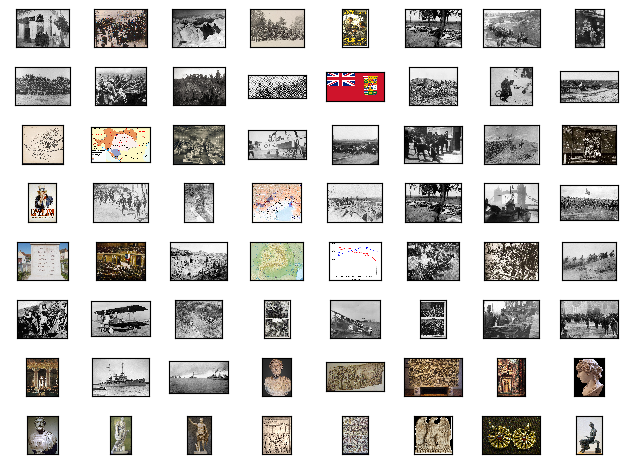

In [21]:
from PIL import Image
import matplotlib.pyplot as plt
import os


def plot_images(image_metadata_dict):
    original_images_urls = []
    images_shown = 0
    for image_id in image_metadata_dict:
        img_path = image_metadata_dict[image_id]["img_path"]
        if os.path.isfile(img_path):
            filename = image_metadata_dict[image_id]["filename"]
            image = Image.open(img_path).convert("RGB")

            plt.subplot(8, 8, len(original_images_urls) + 1)
            plt.imshow(image)
            plt.xticks([])
            plt.yticks([])

            original_images_urls.append(filename)
            images_shown += 1
            if images_shown >= 64:
                break

    plt.tight_layout()


plot_images(image_metadata_dict)

In [20]:
print(image_metadata_dict[1]["img_path"])

data_wiki_2/10.jpg


.//mnt/disk1/sjw/data_wiki_2/1.jpg


In [5]:
def plot_images(image_paths):
    images_shown = 0
    plt.figure(figsize=(16, 9))
    for img_path in image_paths:
        if os.path.isfile(img_path):
            image = Image.open(img_path)

            plt.subplot(2, 3, images_shown + 1)
            plt.imshow(image)
            plt.xticks([])
            plt.yticks([])

            images_shown += 1
            if images_shown >= 9:
                break

In [6]:
from llama_index.core.response.notebook_utils import display_source_node
from llama_index.core.schema import ImageNode

In [7]:
test_query = "What were the key architectural achievements of the Roman Empire, and how are they reflected in modern architecture? "
retriever = index.as_retriever(similarity_top_k=3, image_similarity_top_k=5)
retrieval_results = retriever.retrieve(test_query)

**Node ID:** fc6d31db-3d80-4d12-8f77-77ef8753606b<br>**Similarity:** 0.8656900658653359<br>**Text:** == Architecture and engineering ==

The chief Roman contributions to architecture were the arch, vault and dome. Some Roman structures still stand today, due in part to sophisticated methods of mak...<br>

**Node ID:** 2c20b039-cbda-4de1-8357-08e9d35ed84d<br>**Similarity:** 0.8199881094977175<br>**Text:** === Sculpture and sarcophagi ===

Examples of Roman sculpture survive abundantly, though often in damaged or fragmentary condition, including freestanding statuary in marble, bronze and terracotta,...<br>

**Node ID:** e41f4d74-1805-40d5-af9b-a7be2194c7c7<br>**Similarity:** 0.8074847128718634<br>**Text:** As the classicist Clifford Ando noted:

Most of the cultural appurtenances popularly associated with imperial culture—public cult and its games and civic banquets, competitions for artists, speaker...<br>

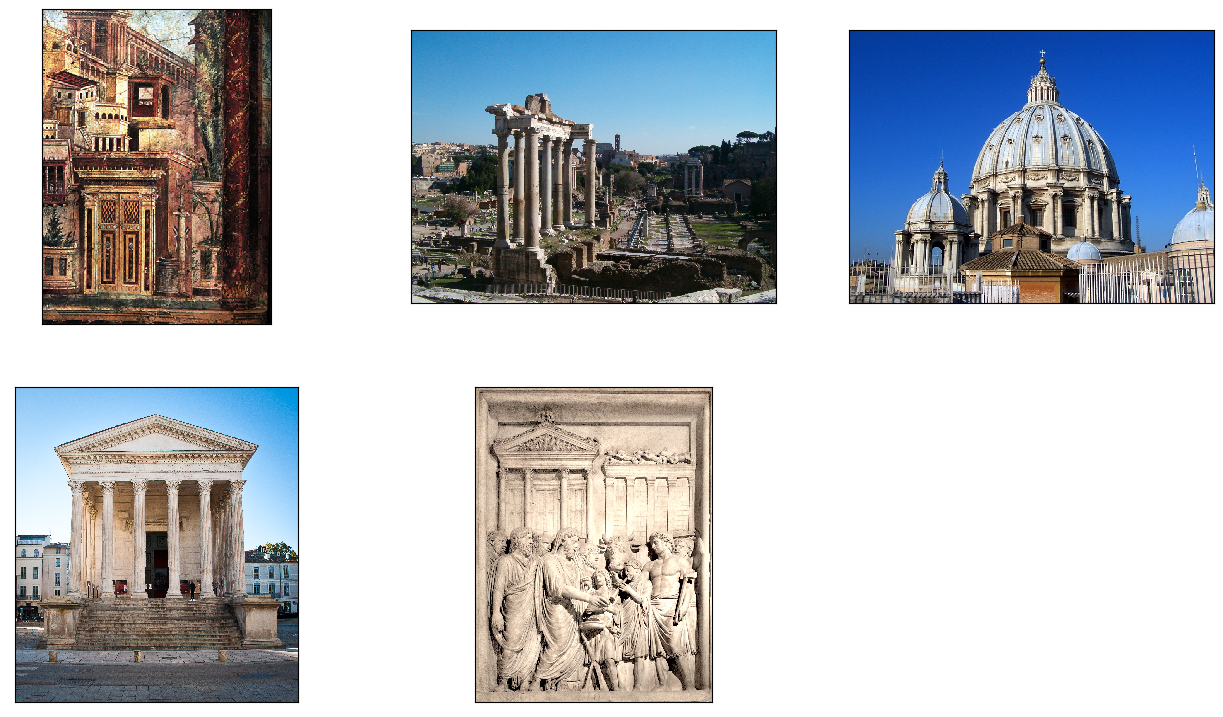

In [8]:
retrieved_image = []
for res_node in retrieval_results:
    if isinstance(res_node.node, ImageNode):
        retrieved_image.append(res_node.node.metadata["file_path"])
    else:
        display_source_node(res_node, source_length=200)

plot_images(retrieved_image)

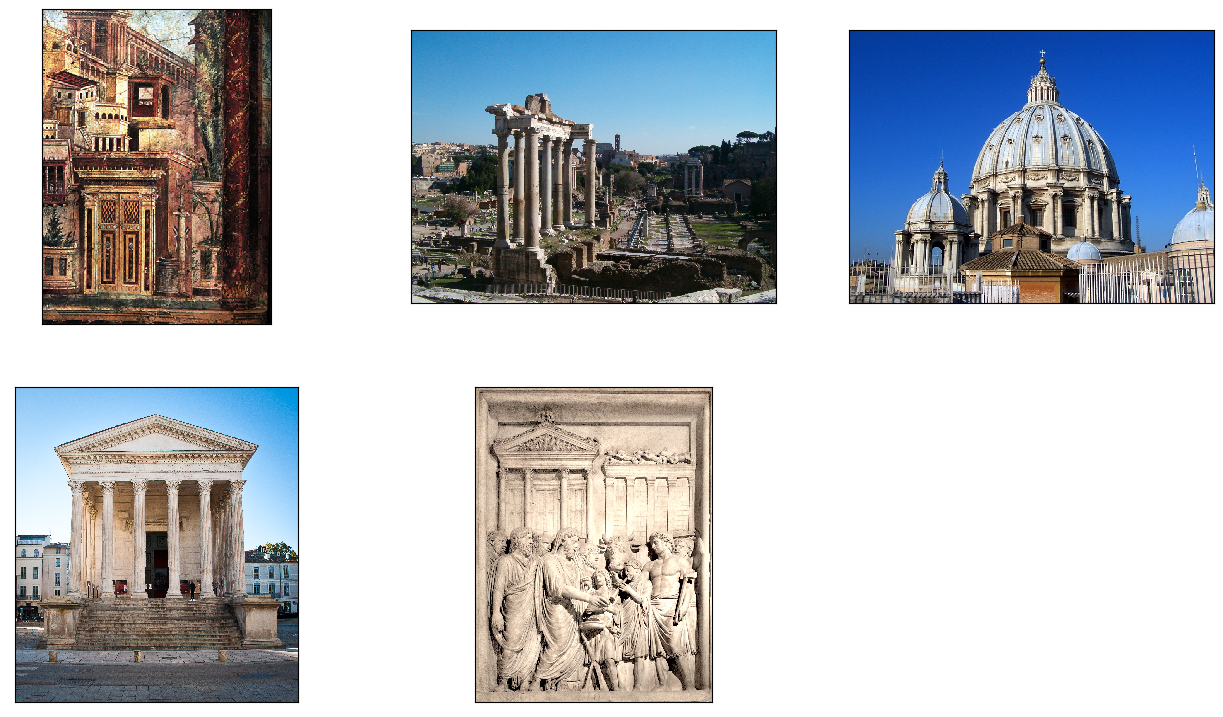

In [9]:
retrieved_image = []
for res_node in retrieval_results:
    if isinstance(res_node.node, ImageNode):
        retrieved_image.append(res_node.node.metadata["file_path"])

plot_images(retrieved_image)

In [12]:
import torch
import clip
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

def get_image_features(image_path):
    image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)
    with torch.no_grad():
        image_features = model.encode_image(image)
    return image_features

def calculate_similarity(image1_path, image2_path):
    features1 = get_image_features(image1_path)
    features2 = get_image_features(image2_path)
    similarity = torch.cosine_similarity(features1, features2)
    return similarity.item()

cnt=0
image2_path = "/mnt/disk1/sjw/gettyimages-480617957-612x612.jpg"
for image in retrieved_image:
    image1_path = retrieved_image[cnt]
    cnt+=1
    similarity = calculate_similarity(image1_path, image2_path)
    print(f"Similarity: {similarity}")

Similarity: 0.57666015625
Similarity: 0.69775390625
Similarity: 0.87255859375
Similarity: 0.65771484375
Similarity: 0.572265625


In [14]:
import torch
import clip
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

def get_image_features(image_path):
    image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)
    with torch.no_grad():
        image_features = model.encode_image(image)
    return image_features

def get_text_features(text):
    text_tokens = clip.tokenize([text]).to(device)
    with torch.no_grad():
        text_features = model.encode_text(text_tokens)
    return text_features

def calculate_similarity(image_path, text):
    image_features = get_image_features(image_path)
    text_features = get_text_features(text)
    
    similarity = torch.cosine_similarity(image_features, text_features)
    return similarity.item()

text_description = "How might architectural practices evolve in the future?"

cnt=0
for image in retrieved_image:
    image1_path = retrieved_image[cnt]
    similarity = calculate_similarity(image1_path, text_description)
    cnt+=1
    print(similarity)

0.240234375
0.2161865234375
0.218505859375
0.217041015625
0.203369140625
